# **M2 Coursework**
fl482

### Set up:

Import dependencies

In [95]:
import copy
import itertools
import json
import numpy as np
import numpy.polynomial.polyutils
import matplotlib.pyplot as plt
import optuna
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.distributions as dist
import torch.nn as nn

Explore data

In [3]:
train_df = pd.read_csv("data/moons_train.csv")
val_df = pd.read_csv("data/moons_val.csv")
test_df = pd.read_csv("data/moons_test.csv")

print(train_df.head())

print(f'\n Max values of train set: \n{train_df[['x1','x2']].max()}\n')
print(f'Min values of train set: \n{train_df[['x1','x2']].min()}')

         x1        x2  class
0  1.925399  0.109340      1
1  0.914507 -0.539689      1
2 -0.715815  0.620555      0
3  0.974094  0.004128      0
4  0.910031  0.447462      0

 Max values of train set: 
x1    2.066934
x2    1.200800
dtype: float64

Min values of train set: 
x1   -1.126840
x2   -0.609939
dtype: float64


Train data: Total number of Class 0 is 385 out of 800
Validation data: Total number of Class 0 is 56 out of 100
Test data: Total number of Class 0 is 59 out of 100


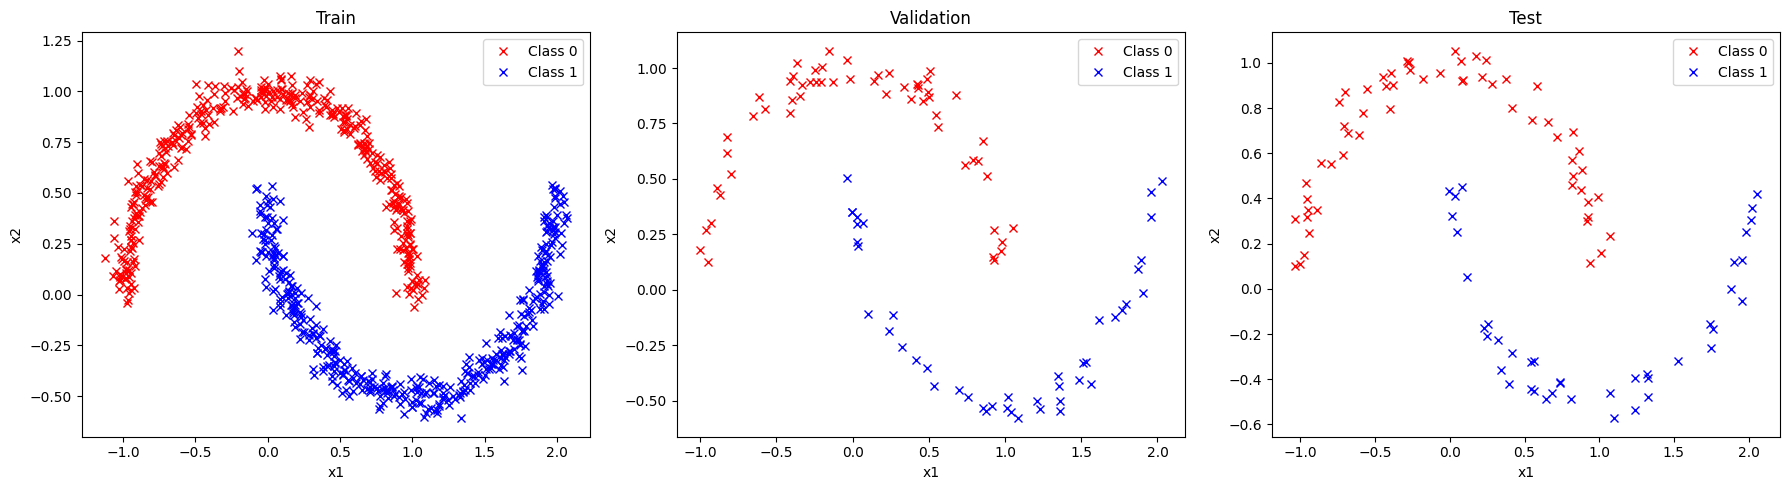

In [4]:
# plotting function for data
def plotdata(*datasets, titles=None):
    n_plots = len(datasets)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
 
    if n_plots == 1:
        axes = [axes]
        
    for i, data in enumerate(datasets):
        ax = axes[i]
        
        class0 = data[data['class'] == 0]
        class1 = data[data['class'] == 1]
        
        ax.plot(class0['x1'], class0['x2'], 'rx', label='Class 0')
        ax.plot(class1['x1'], class1['x2'], 'bx', label='Class 1')
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.legend()
        
        if titles and i < len(titles):
            ax.set_title(titles[i])
            
        class0_count = (data['class'] == 0).sum()
        print(f"{titles[i]} data: Total number of Class 0 is {class0_count} out of {len(data)}")

    plt.tight_layout()
    plt.show()

plotdata(train_df, val_df, test_df, titles=['Train', 'Validation', 'Test'])

The plots of the train, validation and test data show that they consist of two moon clusters that are interlocked. There is slight class inbalance in the training data relative to the validation and test data towards Class 1 (the lower moon). This could result in a model assigning too much density to data from that cluster. 

## **Exercise 1:** *A Mini Normalizing Flow*


### a)
*Implement an affine coupling transform for a 2D vector $h = [h_1 h_2]^T$.* 

*Implement both directions:*
- *the forward map $f[z]$ used for sampling (base → data), and*
- *the inverse map $f^{−1}[x]$ used for evaluating $\log{p[x]}$ (data → base).*
*Your code must return both the transformed output and the log-determinant of the Jacobian for that direction*

In [189]:
# MLP for flow: Linear(1D -> H) -> ReLU -> Linear(H -> 2D)
class CouplingMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim))

    def forward(self, x):
        return self.mlp(x)


class AffineCouplingLayer(nn.Module):
    def __init__(self, hidden_dim, parity):
        super().__init__()
        self.parity = parity
        # input: h (1D), output: s(h) and t(h) (2D)
        self.mlp = CouplingMLP(1, hidden_dim, 2)

    def forward(self, h, inverse=False):
        # split vector based on parity
        h1 = h[:, self.parity:self.parity+1]
        h2 = h[:, 1-self.parity:1-self.parity+1]

        # get s and t from the MLP
        stats = self.mlp(h1)
        s, t = stats.chunk(2, dim=1)
        
        # bound scale output
        s = torch.clamp(s, -2, 2)
        s = torch.tanh(s)

        if not inverse:
            # forward z -> x
            new_h2 = h2 * torch.exp(s) + t
            log_det = torch.sum(s, dim=1)
        else:
            # inverse x -> z
            new_h2 = (h2 - t) * torch.exp(-s)
            log_det = -torch.sum(s, dim=1)

        # reassemble based on parity
        if self.parity == 0:
            return torch.cat([h1, new_h2], dim=1), log_det
        else:
            return torch.cat([new_h2, h1], dim=1), log_det

### b)
*Build a flow with K coupling layers and base density $p[z] = \mathcal{N}(0, I)$. Implement a function that evaluates $\log p[x]$ for a batch of points.*

#### ANSWER
To build the flow we need to implement the following change of variables formula
$$\log p_X(x) = \log p_Z(f^{-1}(x)) + \log \left| \det \frac{\partial f^{-1}}{\partial x} \right|$$

where $z = f^{-1}(x)$ and $\log p_Z(z)$ is the log density of a normal distribution $\mathcal{N}(0, \mathbf{I})$.

Alternating the parity means that $h_1$ and $h_2$ alternate so that the entire dataset will be transformed, not just half.

In [6]:
class NormFlow(nn.Module):
    def __init__(self, n_layers=8, hidden=128):
        super().__init__()
        # stack K coupling layers with alternating parity
        self.layers = nn.ModuleList([
            AffineCouplingLayer(hidden, parity=i % 2) 
            for i in range(n_layers)
        ])
        
    def forward(self, z):
        """Map base distribution z to data x (sampling)."""
        log_det_tot = torch.zeros(z.shape[0], device=z.device)
        for layer in self.layers:
            z, log_det = layer(z, inverse=False)
            log_det_tot += log_det
        return z, log_det_tot

    def inverse(self, x):
        """Map data x to base distribution z."""
        log_det_tot = torch.zeros(x.shape[0], device=x.device)
        # reverse order for the inverse map
        for layer in reversed(self.layers):
            x, log_det = layer(x, inverse=True)
            log_det_tot += log_det
        return x, log_det_tot

    def log_prob(self, x):
        """Evaluate log p(x) for a batch of points."""
        # 1. Map data x to base space z and compute log|det J|
        z, log_det_jacobian = self.inverse(x)
        
        # 2. Evaluate the log density of the base distribution p(z) = N(0, I)
        # For a standard normal, log p(z) = sum_i (-0.5 * log(2*pi) - 0.5 * z_i^2)
        log_p_z = -0.5 * (np.log(2 * np.pi) + z.pow(2)).sum(dim=1)
        
        # 3. Apply the change of variables formula
        log_p_x = log_p_z + log_det_jacobian
        
        return log_p_x

In [ ]:
# quick check
torch.manual_seed(68)
train = torch.tensor(train_df[['x1','x2']].values).float()
model = NormFlow(n_layers=8, hidden=64)
log_likelihoods = model.log_prob(train)

print(f"Mean log-likelihood of batch: {log_likelihoods.mean().item():.4f}")

Batch log p(x) shape: torch.Size([800])
Mean log-likelihood of batch: -8.1963


A quick check of the `log_prob` method on the training data shows that it is working without any errors.

### c)
*Implement the invertibility and log determinant correctness tests.*

#### ANSWER
The invertibility test is implemented by passing the training set through the `inverse` method of the `NormFlow` class and then through the `forward` method. The difference to the original data is then calculated.

In [16]:
def invertibility_test(x):
    torch.manual_seed(68)
    model = NormFlow(n_layers=8, hidden=96)
    model.eval()
    z, _ = model.inverse(x)
    x_hat, _ = model.forward(z)
    errs = torch.abs(x - x_hat)

    return errs

invert_errs = invertibility_test(train)

print(f'Maximum Reconstruction Error: {invert_errs.max()}')


Maximum Reconstruction Error: 8.940696716308594e-07


The invertibility test shows that the forward and inverse transforms are correctly implemented. The value is not exactly 0 due to floating point errors as PyTorch uses 32 bit floats.

For the log-determinant check we use the central difference formula to numerically compute the Jacobian where $e_j$ is the standard basis vector.

$$J_{:, j} \approx \frac{f(x + \epsilon e_j) - f(x - \epsilon e_j)}{2\epsilon}$$

We can then loop through the dimensions to calculate the numerical Jacobian.

In [15]:
def logdet_check(x):
    torch.manual_seed(68)
    model = NormFlow(n_layers=8, hidden=96)
    model.eval()
    x = x[0] # first example
    epsilon = 1e-4

    J_num = torch.zeros(2, 2)

    # loop through dimensions
    for i in range(2):
        x_plus = x.clone()
        x_plus[i] += epsilon
        x_minus = x.clone()
        x_minus[i] -= epsilon
        
        z_plus, _ = model.inverse(x_plus.unsqueeze(0))
        z_minus, _ = model.inverse(x_minus.unsqueeze(0))
        
        J_num[:, i] = (z_plus.squeeze(0) - z_minus.squeeze(0)) / (2 * epsilon)

    logdet_num = torch.log(torch.abs(torch.det(J_num))).item()

    # log determinant from model
    _, logdet_model = model.inverse(x.unsqueeze(0))
    logdet_model = logdet_model.item()

    return abs(logdet_num), abs(logdet_model)

logdet_num, logdet_model = logdet_check(train)
logdet_err = abs(logdet_num - logdet_model)
print(f"Log-det abstract error: {logdet_err}")

Log-det abstract error: 0.0003037452697753906


Plot and save the diagnostic figure. The first panel is a histogram of the reconstruction errors for the training set. The second panel is a bar chart showing thelog determinants for the numerical and analytical Jacobians.

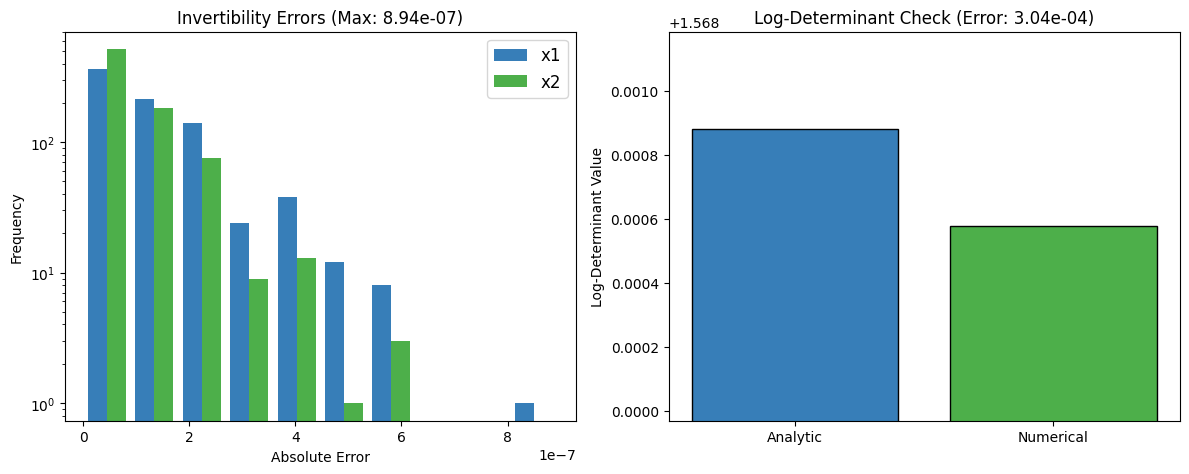

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(invert_errs.detach().numpy(), color=[plt.cm.Set1(0.15), plt.cm.Set1(0.3)], label = ('x1','x2'))
ax1.set_title(f"Invertibility Errors (Max: {invert_errs.max():.2e})")
ax1.set_xlabel("Absolute Error")
ax1.set_yscale('log')
ax1.set_ylabel("Frequency")
ax1.legend(fontsize='large')

labels = ['Analytic', 'Numerical']
values = [logdet_model, logdet_num]
ax2.bar(labels, values, color=[plt.cm.Set1(0.15), plt.cm.Set1(0.3)], edgecolor='black')
ax2.set_title(f"Log-Determinant Check (Error: {logdet_err:.2e})")
ax2.set_ylabel("Log-Determinant Value")
ax2.set_ylim(logdet_model-3*logdet_err,logdet_num+2*logdet_err)
plt.tight_layout()
plt.savefig("figs/Figure1c.pdf")
plt.show()


Save the results and figures

In [28]:
with open('results.json','r') as f:
    results = json.load(f)

results["correctness"]["invertibility_max_abs_error"] = invert_errs.max().item()
results["correctness"]["logdet_finite_diff_abs_error"] = logdet_err

with open('results.json', 'w') as f:
    json.dump(results, f, indent=4)

In [ ]:
#TODO WRITEUP Q1: what the correctness checks show

## **Exercise 2:** *Training Pipeline*

### a)
*Use exactly the first 128 rows of `data/moons_train.csv` as your tiny subset and train on that subset. Plot the loss curves and save them to `figs/Figure2a.pdf`. Record the final tiny-set NLL in `results.json`.*

#### ANSWER
We have already explored the data from the .csv files, however we will check the 'tiny' dataset for any significant differences to the rest of the datasets.

Tiny Dataset data: Total number of Class 0 is 58 out of 128


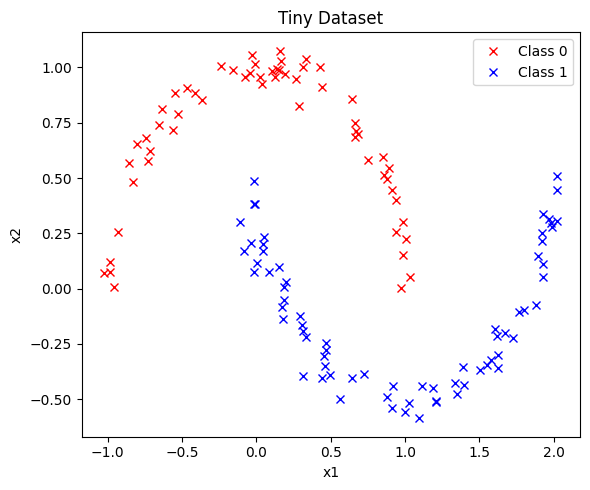

In [29]:
tiny_df = train_df[:128]
plotdata(tiny_df, titles=["Tiny Dataset"])

As seen at the beginning of the notebook the data lies roughly between -1 and 2. There is a class imbalance favouring the lower moon (class 1) which will cause the model to assign slightly higher density values to samples from the lower moon.

As part of the data pre-processing we will apply standard scaling to all the datasets as a best practice although it shouldn't make a large difference in this case. We will also convert the dataframes to PyTorch tensors. The class labels are not going to be used so can be dropped.

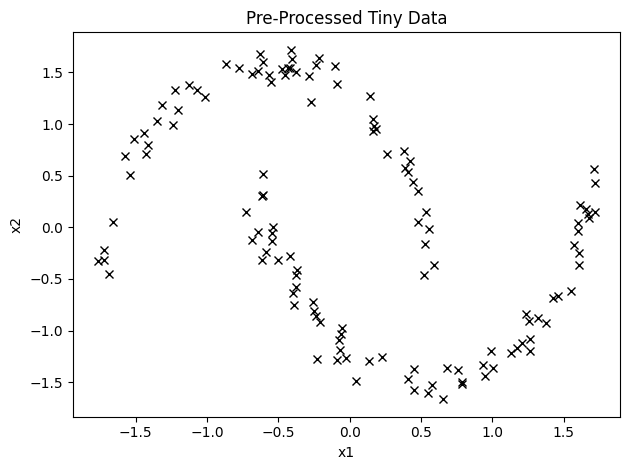

In [31]:
# scaling
scaler = StandardScaler()

# fit scale only to train data and transform all data
train_features = train_df[['x1', 'x2']].values
train_scaled = scaler.fit_transform(train_features)
val_features = val_df[['x1', 'x2']].values
val_scaled = scaler.transform(val_features)
test_features = test_df[['x1', 'x2']].values
test_scaled = scaler.transform(test_features)

# convert to tensors
train = torch.tensor(train_scaled).float()
val = torch.tensor(val_scaled).float()
test = torch.tensor(test_scaled).float()

# take tiny subset
tiny = train[:128]

plt.plot(tiny[:,0], tiny[:,1], 'kx')
plt.title('Pre-Processed Tiny Data')
plt.xlabel('x1')
plt.ylabel('x2')

plt.tight_layout()
plt.show()

The plot shows that the values have not significantly changed and the shape is preserved after preprocessing.

Before any training, we will create a simple 'dumb' baseline to compare our model to. This will be done by fitting a simple 2D Gaussian curve to the mean and variance of the model. We can then calculate the negative log likelihood of this model to set our baseline.

In [98]:
# set base dist
mean = train.mean(dim=0)
cov = torch.cov(train.T)
baseline_dist = dist.MultivariateNormal(mean, cov)

# calc NLL
baseline_nll = -baseline_dist.log_prob(train).mean().item()
print(f"Dumb Baseline NLL: {baseline_nll:.4f}")

Dumb Baseline NLL: 2.7332


Now we have the baseline we are ready to start training. The aim of training on the tiny dataset is to overfit the data and verify that the model can achieve a very small loss value. As a result, we will use a very large model (`n_layer = 8`, `hidden=96`) with the maximum allowed steps (10,000) and no regularisation. This will help us verify that the model architecture has the capacity to completely fit the data.

In [171]:
def tiny_train(n_layers, hidden, tiny, lr, steps):
    torch.manual_seed(68)
    model = NormFlow(n_layers=n_layers, hidden=hidden)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    nll = []
    for step in range(steps):
        optimizer.zero_grad()
        loss = -model.log_prob(tiny).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        nll.append(loss.item())
        
    return nll

tiny_nll = tiny_train(n_layers=8, hidden=96, tiny=tiny, lr=3e-4, steps=10000)

We plot and save the loss curve and write the array to `training_curves.json` as well as the final NLL value to `results.json`.

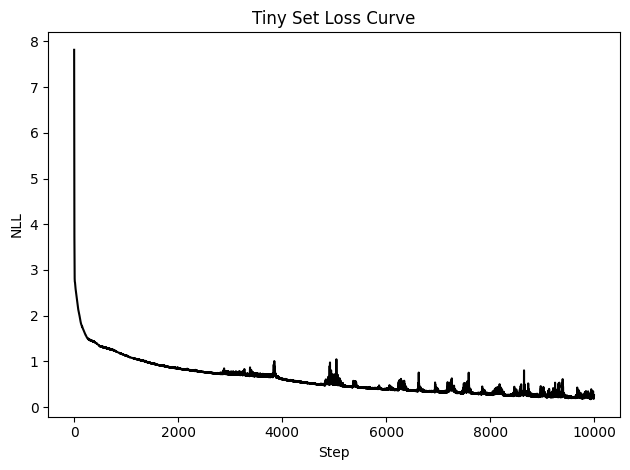

Final NLL value = 0.2578


In [172]:
plt.plot(tiny_nll, c = 'black')
plt.xlabel("Step")
plt.ylabel("NLL")
plt.title("Tiny Set Loss Curve")

plt.tight_layout()
plt.savefig("figs/Figure2a.pdf")
plt.show()

with open("logs/training_curves.json", "r") as f:
    training_curves = json.load(f)

training_curves['tiny_loss'] = tiny_nll

with open("logs/training_curves.json", "w") as f:
    json.dump(training_curves, f, indent=4)

tinyset_final_nll = tiny_nll[-1]
print(f"Final NLL value = {tinyset_final_nll:.4f}")

with open('results.json','r') as f:
    results = json.load(f)

results["training"]["tinyset_final_nll"] = tinyset_final_nll

with open('results.json', 'w') as f:
    json.dump(results, f, indent=4)


The small final loss value shows that the model has the capacity to learn meaningful features of the data and has overfit, which is what we are looking for. Gradient clipping in the training function has prevented most of the significant spiking of the loss, with the noisiness towards the end of the curve suggesting the optimiser is bouncing around a sharp minimum. Given the sharp decrease at the beginning and the noisiness at the end, a cosine annealing learning rate schedule would be appropriate as it would give in a smaller learn rate at the start and end and smoothen out the loss curve.

### b
*Train on `data/moons_train.csv`. Plot the loss curves and save them to `figs/Figure2c.pdf`. Record the final train NLL, final validation NLL, and final test NLL
values in `results.json`.*

#### ANSWER
For the final model we introduce regularisation to improve generalisation and reduce overfitting.
clamping s |s|=2  before tanh layer, improve numerical stability bc range is then ± 0.96 not ±1
weight decay (L2 norm)
Early stopping ensures that the model does not overfit
Learning rate schedule
Hyperparam optimisation w optuna
No dropout due to restrictions

In [190]:
def objective(trial):
    # hperparams to search over: layers, units, learn rate, dropout,L2 reg
    # n_layers = trial.suggest_int('n_layers', 6, 8, step=2)
    n_layers = 8
    hidden = trial.suggest_int('hidden', 80, 96, step=16)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    
    # setup
    torch.manual_seed(68)
    model = NormFlow(n_layers=n_layers, hidden=hidden)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps = 10000 
    patience = 500
    best_val_loss = float('inf')
    patience_counter = 0
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps)
    
    # train
    for step in range(steps):
        model.train()
        optimizer.zero_grad()

        loss = -model.log_prob(train).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        model.eval()
        with torch.no_grad():
            v_loss = -model.log_prob(val).mean().item()
            
        # early stopping
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            # optuna automatically gets best model
            break
            
    return best_val_loss

# run search
study = optuna.create_study(direction='minimize', study_name="NormFlow")
study.optimize(objective, n_trials=15)

print("\\n--- Optuna Search COMPLETE ---")
print(f"Best Trial: {study.best_trial.number}")
print(f"Best Val NLL: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")


[I 2026-03-10 17:12:37,599] A new study created in memory with name: NormFlow
[I 2026-03-10 17:12:50,592] Trial 0 finished with value: 1.2291723489761353 and parameters: {'hidden': 80, 'lr': 5.634204422121982e-05, 'weight_decay': 0.0003058888327542442}. Best is trial 0 with value: 1.2291723489761353.
[I 2026-03-10 17:13:01,728] Trial 1 finished with value: 1.243561863899231 and parameters: {'hidden': 80, 'lr': 6.822768913006502e-05, 'weight_decay': 1.2875530551072782e-06}. Best is trial 0 with value: 1.2291723489761353.
[I 2026-03-10 17:13:15,542] Trial 2 finished with value: 1.4334393739700317 and parameters: {'hidden': 96, 'lr': 9.131744229209804e-05, 'weight_decay': 1.606086246684709e-06}. Best is trial 0 with value: 1.2291723489761353.
[I 2026-03-10 17:13:35,156] Trial 3 finished with value: 1.209232211112976 and parameters: {'hidden': 80, 'lr': 3.63414373202611e-05, 'weight_decay': 7.324595135526544e-06}. Best is trial 3 with value: 1.209232211112976.
[I 2026-03-10 17:14:07,767] T

\n--- Optuna Search COMPLETE ---
Best Trial: 3
Best Val NLL: 1.2092
Best Hyperparameters:
    hidden: 80
    lr: 3.63414373202611e-05
    weight_decay: 7.324595135526544e-06


Optuna Best Hyperparameters:
-   `n_layers`: 8
-   `hidden`: 80
-   `lr`: 3.1710152109884516e-05
-   `weight_decay`: 5.050016169805197e-05

In [191]:
def train_model(n_layers, hidden, train_data, val_data, lr, weight_decay, steps):
    torch.manual_seed(68)
    model = NormFlow(n_layers=n_layers, hidden=hidden)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps)
    
    best_val_loss = float('inf')
    patience = 1000
    patience_counter = 0

    train_nll = []
    val_nll = []
    for step in range(steps):
        model.train()
        optimizer.zero_grad()
        
        loss = -model.log_prob(train_data).mean()
        train_nll.append(loss.item())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        model.eval()
        with torch.no_grad():
            val_loss = -model.log_prob(val_data).mean()
            val_nll.append(val_loss.item())

        # early stopping
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            # Save a deep copy of the best model weights
            best_model_state = copy.deepcopy(model.state_dict())
            best_step = step
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early stopping triggered at step {step}. Best Val Loss: {best_val_loss:.4f} at step {best_step}")
            break
    return train_nll, val_nll, best_model_state, best_step

n_layers = 8
hidden = 80
lr = 3.1710152109884516e-05
l2 = 5.050016169805197e-06
train_nll, val_nll, best_model, step = train_model(n_layers, hidden, train, val, lr, l2, 10000)

Early stopping triggered at step 5623. Best Val Loss: 1.2144 at step 4623


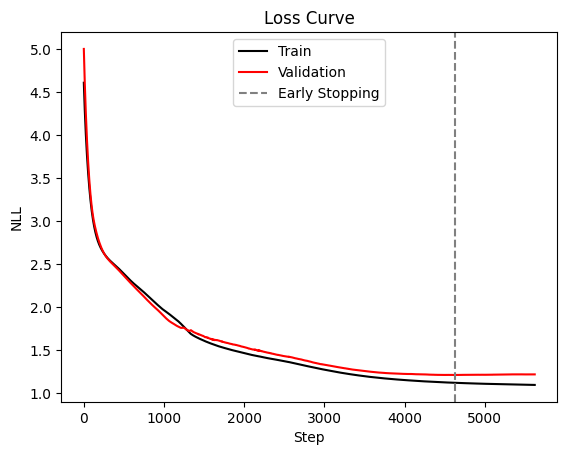

Final train loss: 1.1238055229187012
Final validation loss: 1.2144286632537842
Final test loss: 1.3801360130310059


In [192]:
# plot loss curves
plt.plot(train_nll, c = 'black', label = 'Train')
plt.plot(val_nll, c = 'red', label = 'Validation')
plt.axvline(x=step, color='gray', linestyle='--', label='Early Stopping')
plt.xlabel("Step")
plt.ylabel("NLL")
plt.title("Loss Curve")
plt.legend()

plt.savefig("figs/Figure2c.pdf", bbox_inches='tight')
plt.show()

# calc final losses
torch.manual_seed(68)
model = NormFlow(n_layers=n_layers, hidden=hidden)
model.load_state_dict(best_model)
model.eval()

with torch.no_grad():
    final_train_nll = -model.log_prob(train).mean().item()
    final_val_nll = -model.log_prob(val).mean().item()
    final_test_nll = -model.log_prob(test).mean().item()

print(f'Final train loss: {final_train_nll}')
print(f'Final validation loss: {final_val_nll}')
print(f'Final test loss: {final_test_nll}')

As a final check of the model, we can generate some data from a standard normal distribution and see how well the model transforms it. We can also visually check the invertibility by performing an inverse transform back into a standard normal distribution.

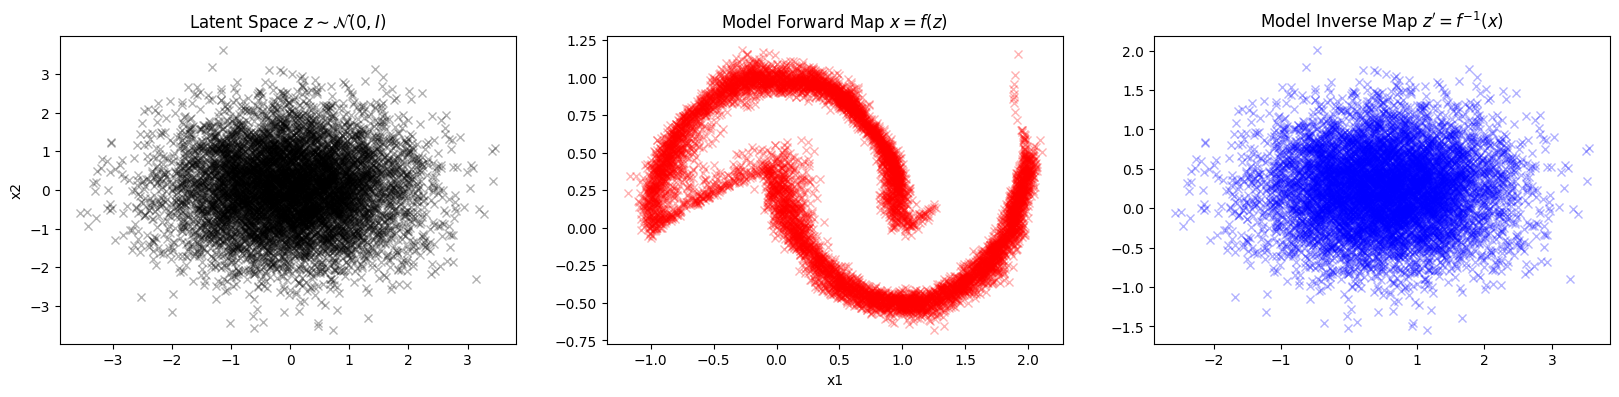

In [194]:
torch.manual_seed(68)
z = torch.randn(8000, 2)

x, _ = model.forward(z)
z2, _ = model.inverse(x)

x = scaler.inverse_transform(x.detach().numpy())

z2 = scaler.inverse_transform(z2.detach().numpy())


fig, axes = plt.subplots(1, 3, figsize=(20, 4))

axes[0].plot(z[:,0],z[:,1],'kx',alpha=0.3, label = 'Sample')
axes[1].plot(x[:,0],x[:,1],'rx',alpha=0.3, label = 'Transform')
axes[2].plot(z2[:,0],z2[:,1],'bx',alpha=0.3, label = 'Transform 2')
axes[1].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title(r'Latent Space $z \sim \mathcal{N}(0, I)$')
axes[1].set_title(r'Model Forward Map $x = f(z)$')
axes[2].set_title(r'Model Inverse Map $z^\prime = f^{-1}(x)$')

plt.show()

<!-- The forward transformation shows that the model has learned the pattern but perhaps overfit slightly as it is fitting some of the training data noise. This is seen in the red plot where at the top of the upper moon there is a 'tuft' of points. This can be explained by recalling that the graph of the training data `moons_train.csv` has one outlier point at roughly the same place. -->

As can be seen in the forward map, our model has learnt the shape of the moons data but seems to struggle at the tips of the moons. The 'bridge' of points between the moons occurs because the mapping must be continuous so the model most connect the two moons with an area of very low density which is exposed when sampling lots of points. 

Having verified the model is good, we can save the model checkpoints and training log

In [181]:
# save checkpoints
os.makedirs("checkpoints", exist_ok=True)
checkpoint = {
    "state_dict": best_model,
    "config": {
        "n_layers": n_layers,
        "hidden": hidden,
    },
    "seed": 68
}
torch.save(checkpoint, "checkpoints/flow_full.pt")


# update results.json
with open("results.json", "r") as f:
    results = json.load(f)

results["training"]["final_train_nll"] = final_train_nll
results["training"]["final_val_nll"] = final_val_nll
results["training"]["final_test_nll"] = final_test_nll

with open("results.json", "w") as f:
    json.dump(results, f, indent=4)


# save logs
with open("logs/training_curves.json", "r") as f:
    training_curves = json.load(f)

training_curves["full_loss"] = train_nll
training_curves["full_val_loss"] = val_nll

with open("logs/training_curves.json", "w") as f:
    json.dump(training_curves, f, indent=4)


In [126]:
#TODO WRITEUP Q2: Explain training choices and diagnostics 
# that inform final run

## **Exercise 3:** *Flow Surgery: A One-Parameter Family of Densities*

### a)
*Define an invertible map $g_{\alpha} : \mathbb{R}^2 \rightarrow \mathbb{R}^2$ by the shear*

$$
\begin{bmatrix}
y_1 \\
y_2
\end{bmatrix} = g_{\alpha} \left[ \begin{bmatrix}
x_1 \\
x_2
\end{bmatrix} \right] = \begin{bmatrix}
x_1 + \alpha x_2 \\
x_2
\end{bmatrix}.
$$

*Implement* $g_\alpha[·]$ *and its inverse* $g^{-1}_\alpha[·]$*, returning both the transformed output and the
log-determinant for that direction.*

#### ANSWER
The forward map can be written as

$$\begin{bmatrix} y_1 \\ y_2 \end{bmatrix} = \begin{bmatrix} 1 & \alpha \\ 0 & 1 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} x_1 + \alpha x_2 \\ x_2 \end{bmatrix}$$

The Jacobian matrix $J$ is then given by 

$$J = \begin{bmatrix} \frac{\partial y_1}{\partial x_1} & \frac{\partial y_1}{\partial x_2} \\ \frac{\partial y_2}{\partial x_1} & \frac{\partial y_2}{\partial x_2} \end{bmatrix} = \begin{bmatrix} 1 & \alpha \\ 0 & 1 \end{bmatrix}$$

Since the determinant $\det(J) = (1 \cdot 1) - (\alpha \cdot 0) = 1$, the log-determinant is $\log(1) = 0$ indicating that the transformation is volume preserving.

To find the inverse map, we solve for $x_1$ and $x_2$ in terms of $y_1$ and $y_2$. From the second equation, we trivially get: $$ x_2 = y_2 $$

Substituting this back into the first equation $$ y_1 = x_1 + \alpha x_2 \implies y_1 = x_1 + \alpha y_2 $$ $$ x_1 = y_1 - \alpha y_2 $$

Thus, the inverse map is $$ \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = g_\alpha^{-1}\begin{bmatrix} y_1 \\ y_2 \end{bmatrix} = \begin{bmatrix} y_1 - \alpha y_2 \\ y_2 \end{bmatrix} $$

And the Jacobian of the inverse map $J_{g_\alpha^{-1}}$ is $$ J_{g_\alpha^{-1}} = \begin{bmatrix} \frac{\partial x_1}{\partial y_1} & \frac{\partial x_1}{\partial y_2} \\ \frac{\partial x_2}{\partial y_1} & \frac{\partial x_2}{\partial y_2} \end{bmatrix} = \begin{bmatrix} 1 & -\alpha \\ 0 & 1 \end{bmatrix} $$

The determinant here is $(1 \times 1) - (-\alpha \times 0) = 1$, and its log-determinant is also $\log|1| = 0$.

In [127]:
class ShearMap(torch.nn.Module):
    def __init__(self, alpha):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        """
        Applies the forward shear map y = g_alpha(x).
        Inputs:
            x: Tensor of shape (batch_size, 2)
        Outputs:
            y: Transformed tensor
            log_det: Log-determinant of the Jacobian (zeros)
        """
        y = torch.empty_like(x)
        y[:, 0] = x[:, 0] + self.alpha * x[:, 1]
        y[:, 1] = x[:, 1]
        
        # log|det(J)| = 0
        log_det = torch.zeros(x.shape[0], device=x.device)
        return y, log_det

    def inverse(self, y):
        """
        Applies the inverse shear map x = g_alpha^{-1}(y).
        Inputs:
            y: Tensor of shape (batch_size, 2)
        Outputs:
            x: Inversely transformed tensor
            log_det: Log-determinant of the inverse Jacobian (zeros)
        """
        x = torch.empty_like(y)
        x[:, 0] = y[:, 0] - self.alpha * y[:, 1]
        x[:, 1] = y[:, 1]
        
        # log|det(J)| = 0
        log_det = torch.zeros(y.shape[0], device=y.device)
        return x, log_det


### b)
*Load the trained model from `checkpoints/flow_full.pt`. Let $f_0[z]$ denote the corresponding trained sampling map (base → data). Define a new sampling map* $f_\alpha[z] = g_\alpha[f_0[z]]$. *This induces a family of densities* $p_\alpha[x]$. *For this coursework, implement this by appending the deterministic map* $g_\alpha$ *after your trained flow. Do not retrain after the edit. Without retraining, generate samples for exactly the five values*

$$\alpha \isin {−2, −1, 0, 1, 2}$$

*and include them as a panel in `figs/Figure3b.pdf`.*

In [128]:
# function to load model
def loadmodel(filepath):
    """Load model from saved checkpoint with correct configs"""
    checkpoint = torch.load(filepath, map_location=torch.device('cpu'))
    config = checkpoint["config"]
    
    model = NormFlow(
        n_layers=config["n_layers"], 
        hidden=config["hidden"])

    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    return model

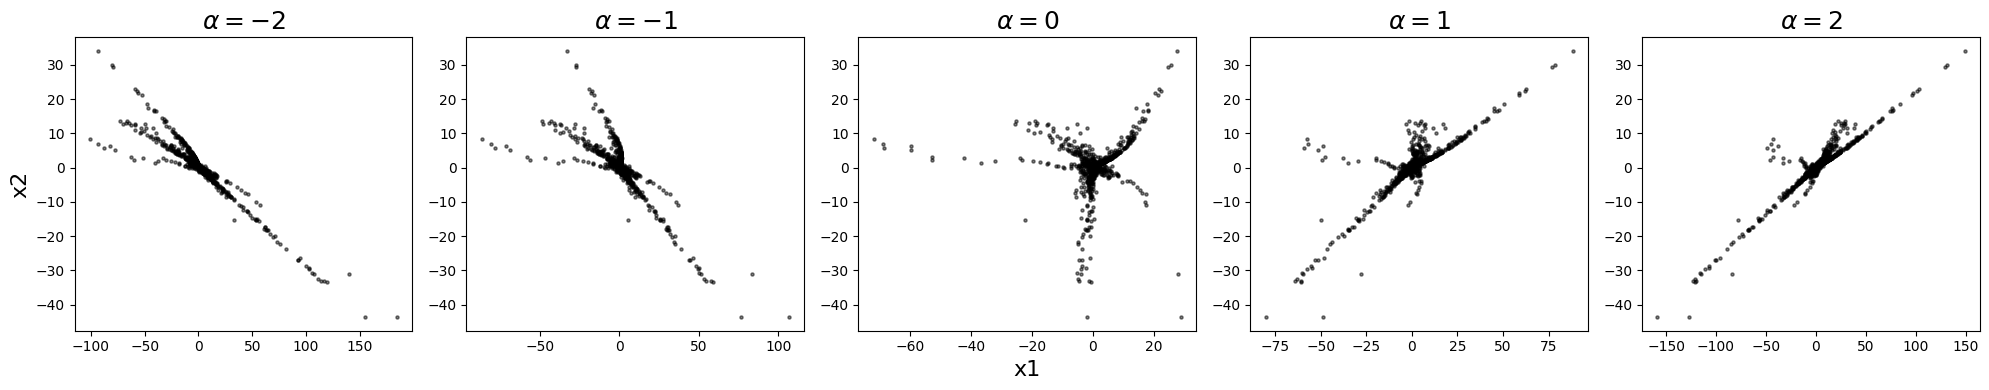

In [188]:
torch.manual_seed(68)
# load model
model = loadmodel("checkpoints/flow_full.pt")

# generate samples from standard normal
num_samples = 1000
z = torch.randn(num_samples, 2)

# calc and plot
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

alphas = [-2, -1, 0, 1, 2]
for i, alpha in enumerate(alphas):

    g_alpha = ShearMap(alpha)
    
    # 4. Compose: first pass through trained flow f_0, then through g_alpha
    with torch.no_grad():
        # f_0(z) = x
        x_0, _ = model.inverse(z) 
        # f_alpha(x) = g_alpha(f_0(z))
        x_alpha, _ = g_alpha(x_0)
    
    # back to original scale
    x_alpha = scaler.inverse_transform(x_alpha.numpy())
    
    # Plot the sample
    axes[i].scatter(x_alpha[:, 0], x_alpha[:, 1], s=5, alpha=0.5, c='black')
    axes[i].set_title(f"$\\alpha = {alpha}$", fontsize = 18)
axes[2].set_xlabel('x1', fontsize = 16)
axes[0].set_ylabel('x2', fontsize = 16)

plt.tight_layout()
plt.savefig("figs/Figure3b.pdf")
plt.show()


In [ ]:
#TODO WRITEUP Q3: What the surgery map changes
# AI answer
# "The surgery map acts as a deterministic, volume-preserving (log-det is 0) shear transformation on the generated samples. It geometrically skews the learned data distribution along the x1-axis depending on the parameter $\alpha$ without altering the total density volume or requiring retraining of the flow base."

## **Exercise 4:** *FLOP Counting Function*

Use the following idealised FLOP costs:

| Operation | FLOPs |
| :--- | :--- |
| Addition/Subtraction/Negation (float OR integer) | 1 |
| Multiplication/Division/Inverse (float OR integer) | 1 |
| ReLU/Absolute Value | 1 |
| Exponentiation/Logarithm/Tanh/Sigmoid | 10 |
| Sine/Cosine/Square Root | 10 |
| Base-density evaluation per example | 20 |

### a)
*Consider evaluating $\log p[x]$ for a batch of size $B$ for your flow (including the inverse pass, log-det, and the base log-density). Do not answer this by tracing or manually tallying PyTorch operations from a particular run. The point is to derive the count from the mathematics of the model rather than from a particular run. You may ignore Python overhead, indexing, and data loading. You may ignore optimiser overhead (Adam, momentum buffers, etc.). State clearly any additional simplifying assumptions you make in `results.json` under `writeup`.*

#### Initial Quantities
For a single batch of the flow 
Let $B$ be `batch_size`, $D$ be `dim` (2), $H$ be `hidden`, and $K$ be `n_layers`. Because we split the input in half in an affine coupling layer, let $d = D / 2$ be the dimension of the masked half.

#### MLP
To start, we will break down how many FLOPs a single pass of the MLP costs, Linear(d -> H) -> ReLU -> Linear(H -> 2d).

Linear(d -> H) (Weights $W_1$ and Bias $b_1$)
- Multiply $d \times B$ inputs for each of the $H$ outputs, $B \times H \times d$ multiplications. (Weights $W_1$)
- Add the products together across dimensions $B \times H \times (d - 1)$ additions
- $B \times H$ additions for the biases ($b_1$)
- TOTAL: $2 \cdot B \cdot H \cdot d$ FLOPs

ReLU
- Apply to $H$ neurons
- TOTAL: $B \cdot H$ FLOPs

Linear(H -> 2d) (Weights $W_2$ and Bias $b_2$)
- Multiply $H$ inputs for each of the $2d$ outputs, $B \times 2d \times H$ multiplications. (Weights $W_2$)
- Add the products together across dimensions $B \times 2d \times (H - 1)$ additions.
- $B \times 2d$ additions additions for the biases ($b_2$)
- TOTAL: $4 \cdot B \cdot H \cdot d$ FLOPs

**TOTAL MLP FLOPs PER LAYER: $B \cdot H \cdot (6d + 1)$**

#### Coupling Transform and log det
The MLP outputs are split into $s$ and $t$, each with dimension $d$. Then we apply the transformation on the unmasked half of $x$. We assume both $s$ and $t$ have already been calculated so do not require extra FLOPs.

Output Scale $s = tanh(s)$
- Apply $tanh$ to each element in $s$ which costs 10 FLOPs each time.
- TOTAL: $10 \cdot B \cdot d$


The inverse pass: $h_2 = (h^\prime_2 - t(h^\prime_1)) ⊙ \exp(-s(h^\prime_1))$
- Subtraction ($h^\prime_2 - t(h^\prime_1)$): $1$ FLOP per element in $d$ so $ B \cdot d$
- Negation ($-s(h^\prime_1)$): $1$ FLOP per element in $d$ so $B \cdot d$
- Exponential ($\exp$): $10$ FLOPs per element in $d$ so $10 \cdot B \cdot d$
- Multiplication ($⊙$): $1$ FLOP per element in $d$ so $B \cdot d$
- TOTAL: $13 \cdot B \cdot d$

The log-det term: $-\sum{s(h^\prime_1)}$
- We sum $s$ over dimension 1 (which has $d$ elements). Summing $d$ elements takes $d-1$ additions per $B$.
- In this calculation the negation FLOPS ($B \cdot d$) are included but it could be safe to assume the values of $-s$ are cached from before and not include the FLOPs.
- TOTAL: $B \cdot (2d - 1)$

**TOTAL COUPLING + LOG DET FLOPs PER LAYER**: $B(25d - 1)$

#### Cost with Layers
- Since there are $K$ layers, we multiply the per-layer costs by $K$ to give $K \times [ B \cdot H \cdot (6d + 1) + 25Bd - B ]$ 
- The `log_det_tot` variable also updates every loop which costs $K \cdot B$ FLOPs
- **TOTAL COST FOR LAYERS:** $K[ B \cdot H \cdot (6d + 1) + 25Bd ]$



#### Base Density 
$log(p_x) = log(p_z) + log |\det(J)|$
- From the table, base-density evaluation ($log(p_z)$) costs 20 FLOPs per datapoint so the cost is $20B$
- The base density is then added to the Jacobian log determinant which costs $B$ FLOPs
- TOTAL: $21B$

#### **FINAL COST**
The final total is $$K \cdot B \left( H (6d + 1) + 21d \right) + 21B$$
In terms of $D$ it is $$K \cdot B \left( H (3D + 1) + 12.5D \right) + 21B$$

Using the values from our best model with data from `moons_train.csv`: 
- $K$ = `n_layers` = 8, 
- $H$ = `hidden` = 96,
- $B$ = batch size = 800
- $D$ = dimensions = 2

**NUMERICAL TOTAL = $\mathbf{3,760,800}$ FLOPs**

### b)
Implement a function in your notebook with the exact signature:

```python
def count_flops(*, dim: int, n_layers: int, hidden: int, batch_size: int) -> int:
```

Your implementation should compute the formula from the architecture described below; it should not inspect a live PyTorch graph or count operations one-by-one during execution. The integer arguments are:
- `dim` (this coursework uses `dim=2`, but your function should be more general and should
handle even values of `dim`),
- `n_layers` (total number K of coupling layers; assume K is even and the two mask/permutation patterns alternate, so each pattern appears K/2 times),
- `hidden` (width of the MLP in each coupling layer), and
- `batch_size`.

Assume each coupling layer uses one MLP of the form
Linear(D → H) → ReLU → Linear(H → 2D),
followed by splitting into $s[·]$ and $t[·]$ and applying $s ← tanh[s]$. Assume your `logprob`
evaluation uses the inverse pass. Your function should return the number of FLOPs needed to compute $\log p[x]$ for one batch.

In [132]:
def count_flops(*, dim: int, n_layers: int, hidden: int, batch_size: int):
    """
    Calculate the theoretical FLOP count for a batch of `batch_size` through `n_layers` 
    of the flow model.
    """
    # D = dim, K = n_layers, H = hidden, B = batch_size
    # formula is K * B * (H * (3D + 1) + 12.5D) + 21B
    total_flops = n_layers * batch_size * (hidden * (3*dim +1) +12.5*dim) + 21*batch_size
    return int(total_flops)
    
flops = count_flops(dim=2, n_layers=8, hidden=80, batch_size=800)
print(f"Total FLOPs: {flops:,}")

Total FLOPs: 3,760,800


The function is implemented correctly as a check using the variables of the best model gives the same value as the manual computation in Exercise 4a.